In [59]:
import os
import torch
import random
import numpy as np
import pandas as pd
from torch import nn
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Dataset, DataLoader
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights, resnet18, efficientnet_b0, EfficientNet_B0_Weights

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
def build_transforms(crop_size=256, augment=True):
    # paired transforms (image & mask transformed together)
    if augment:
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),

            v2.RandomCrop(crop_size),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.2)
        ])
    else:
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True)
        ])

class CrackSegmentationDataset(Dataset):
    def __init__(self, paths, crop_size=256, augment=True):
        self.paths = paths

        self.images = []
        self.masks = []

        for img_path, mask_path in tqdm(paths):
            self.images.append(Image.open(img_path).convert("RGB"))
            self.masks.append(Image.open(mask_path).convert("1"))
        
        self.transform = build_transforms(crop_size, augment)
        self.crop_size = crop_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image, mask = self.transform(self.images[idx], self.masks[idx])
        return image, mask

In [11]:
def list_examples(path: Path):
    # dataset structure:
    # images: $path/images/xxx
    # masks:  $path/masks/xxx
    # return tuples (image_path, mask_path)
    images_path = path / "images"
    masks_path = path / "masks"
    examples = []
    for img_file in images_path.iterdir():
        mask_file = masks_path / img_file.name
        if mask_file.exists():
            examples.append((img_file, mask_file))

    return examples

In [12]:
all_train_examples = list_examples(Path("train"))

# 80 / 20 split for training and validation sets
random.shuffle(all_train_examples)
split_idx = int(0.8 * len(all_train_examples))

train_examples = all_train_examples[:split_idx]
valid_examples = all_train_examples[split_idx:]

test_examples = list_examples(Path("test"))

# take a subset of dataset for quick testing
# rng = random.Random(42)
# train_examples = rng.sample(list_examples(Path("train")), 500)
# test_examples = rng.sample(list_examples(Path("test")), 80)

In [15]:
# train_dataset = CrackSegmentationDataset(train_examples)
# valid_dataset = CrackSegmentationDataset(valid_examples, augment=False)
test_ds = CrackSegmentationDataset(test_examples, augment=False)

## EfficientNet_b0

In [18]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

In [19]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [20]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(1280, 1)
)

In [21]:
model.to(device);

In [22]:
checkpoint = torch.load('model_checkpoints/effnet_b0.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval();

## GradCam

In [53]:
def grad_cam_segmentation(model, input_tensor, target_layers, thresh=0.5):
    model.eval()
    batch_size = input_tensor.size(0)
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)

    # ---- 1) Forward pass for predictions ----
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits).squeeze(1)
        preds = probs > 0.5

    # ---- 2) Prepare Grad-CAM ----
    cam = GradCAM(model=model, target_layers=target_layers)

    # Keep only positive cases for GradCAM input
    positive_idx = preds.nonzero(as_tuple=True)[0]

    if len(positive_idx) == 0:
        # No positive detections → return zero masks
        return torch.zeros((batch_size, *input_tensor.shape[-2:]))

    pos_inputs = input_tensor[positive_idx]  # shape (N_pos, C, H, W)
    targets = [BinaryClassifierOutputTarget(1)] * len(positive_idx)

    # ---- 3) Compute Grad-CAM heatmaps ----
    grayscale_cams = cam(input_tensor=pos_inputs, targets=targets)
    grayscale_cams = torch.from_numpy(grayscale_cams).to(device)  # (N_pos, H, W)

    # ---- 4) Threshold to get binary segmentation mask ----
    pos_masks = (grayscale_cams > thresh).float()

    # ---- 5) Reassemble masks back into batch shape ----
    H, W = grayscale_cams.shape[1:]
    final_masks = torch.zeros(batch_size, H, W, device=device)

    for mask, idx in zip(pos_masks, positive_idx):
        final_masks[idx] = mask

    return final_masks

## Evaluation

In [54]:
def compute_metrics(preds: torch.Tensor, target: torch.Tensor, eps=1e-8):
    """Compute IoU, precision, recall, F1 for binary masks."""
    preds = preds.int()
    target = target.int()

    intersection = (preds & target).sum(dim=(1, 2, 3))
    union = (preds | target).sum(dim=(1, 2, 3))
    iou = (intersection + eps) / (union + eps)

    true_pos = intersection
    false_pos = ((preds == 1) & (target == 0)).sum(dim=(1, 2, 3))
    false_neg = ((preds == 0) & (target == 1)).sum(dim=(1, 2, 3))

    precision = (true_pos + eps) / (true_pos + false_pos + eps)
    recall = (true_pos + eps) / (true_pos + false_neg + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)

    return iou.mean().item(), precision.mean().item(), recall.mean().item(), f1.mean().item()

In [55]:
def inference(model, images):
    # images: (B, C, H, W)
    return grad_cam_segmentation(model, images, [model.features[8]], thresh=0.5)

def evaluate_on_dataset(test_dataset):
    total_iou = 0.0
    total_prec = 0.0
    total_rec = 0.0
    total_f1 = 0.0

    for i in tqdm(range(len(test_dataset)), desc="evaluation..."):
        image, mask = test_dataset[i]
        image = image.unsqueeze(0).to(device)      # (1, C, H, W)
        true_mask = mask[None, None].to(device)    # (1, 1, H, W)

        pred_mask = inference(model, image).to(device)

        # ---- use your helper ----
        iou, prec, rec, f1 = compute_metrics(pred_mask, true_mask)

        total_iou  += iou
        total_prec += prec
        total_rec  += rec
        total_f1   += f1

    avg_iou = total_iou / len(test_dataset)
    avg_prec = total_prec / len(test_dataset)
    avg_rec  = total_rec / len(test_dataset)
    avg_f1   = total_f1 / len(test_dataset)

    print(f"Average IoU:  {avg_iou:.4f}")
    print(f"Precision:    {avg_prec:.4f}")
    print(f"Recall:       {avg_rec:.4f}")
    print(f"F1-score:     {avg_f1:.4f}")

evaluation...:   0%|          | 0/1695 [00:00<?, ?it/s]

Average IoU:  0.3889
Precision:    0.7331
Recall:       0.5310
F1-score:     0.4069


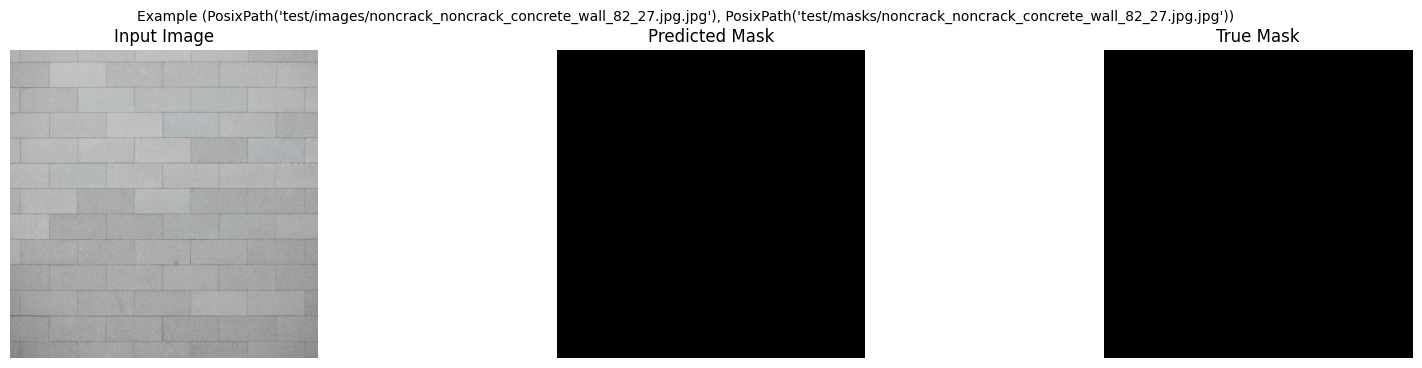

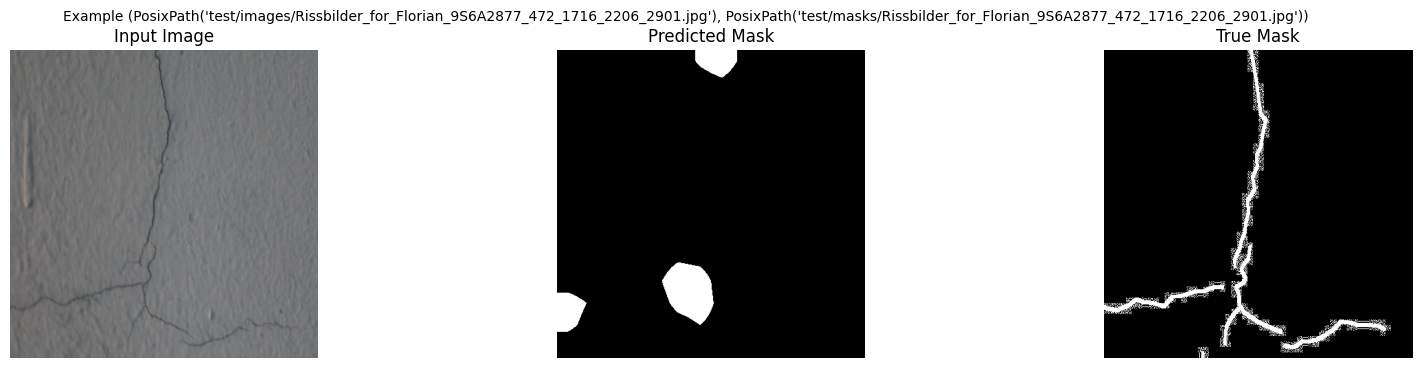

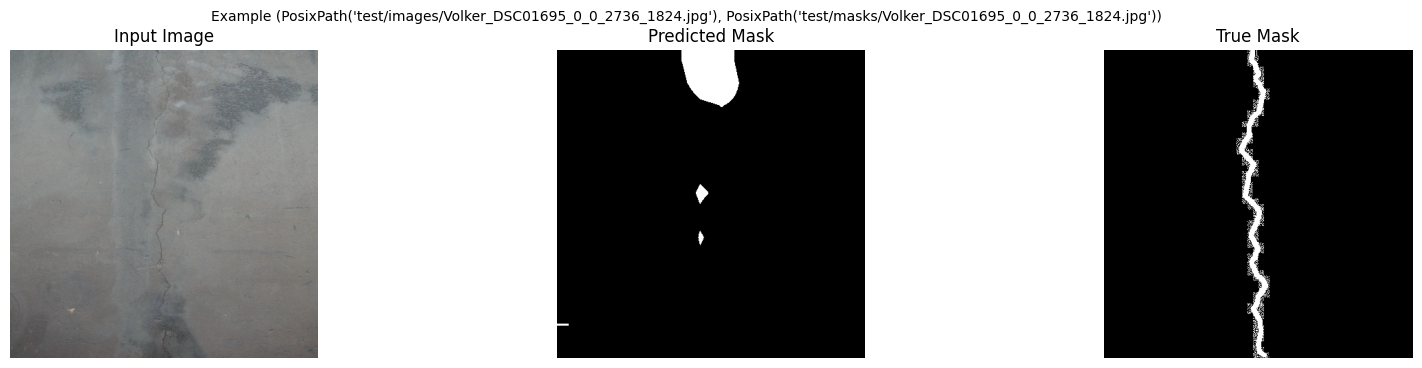

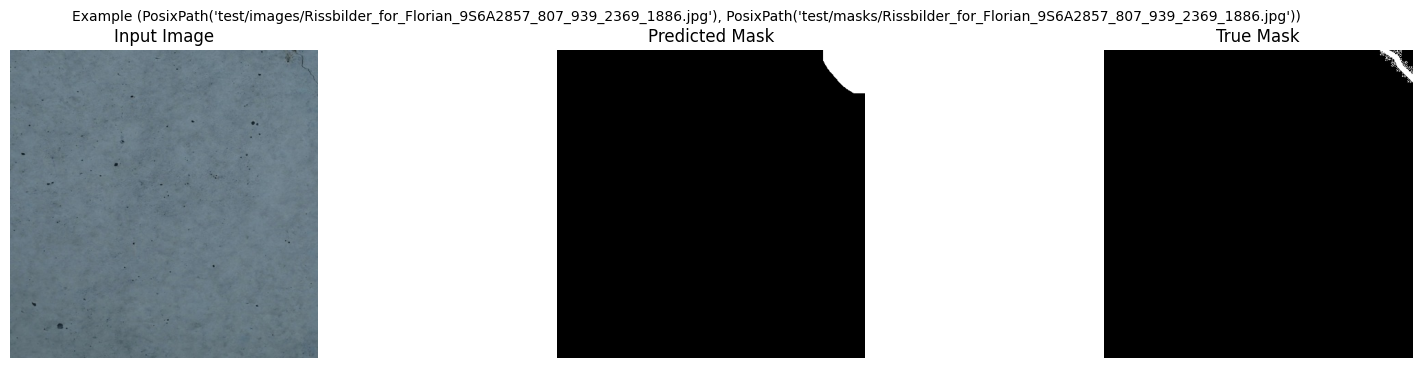

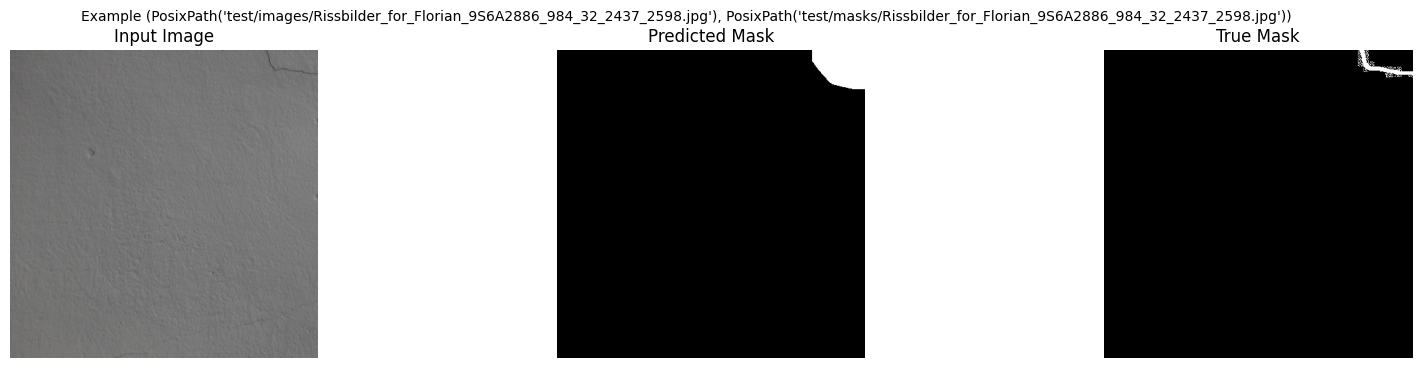

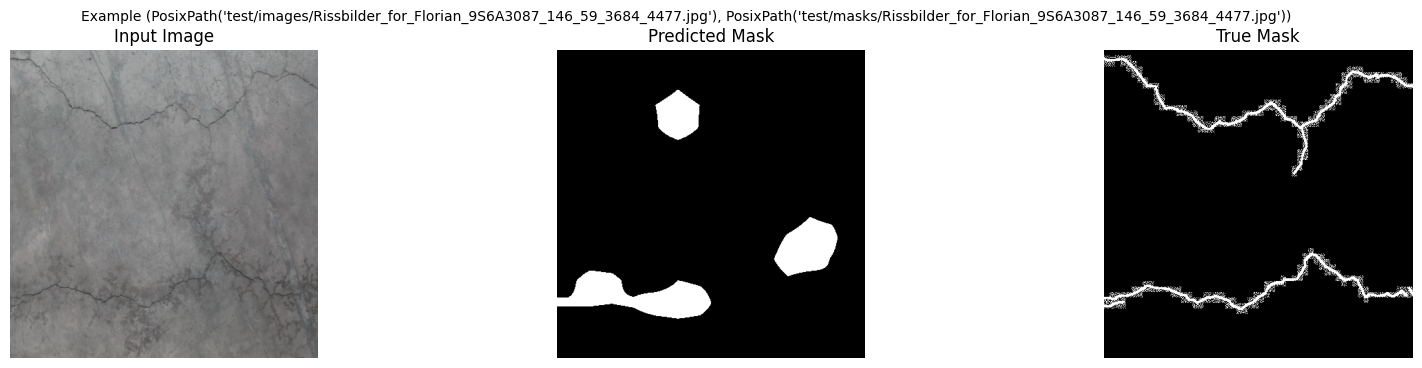

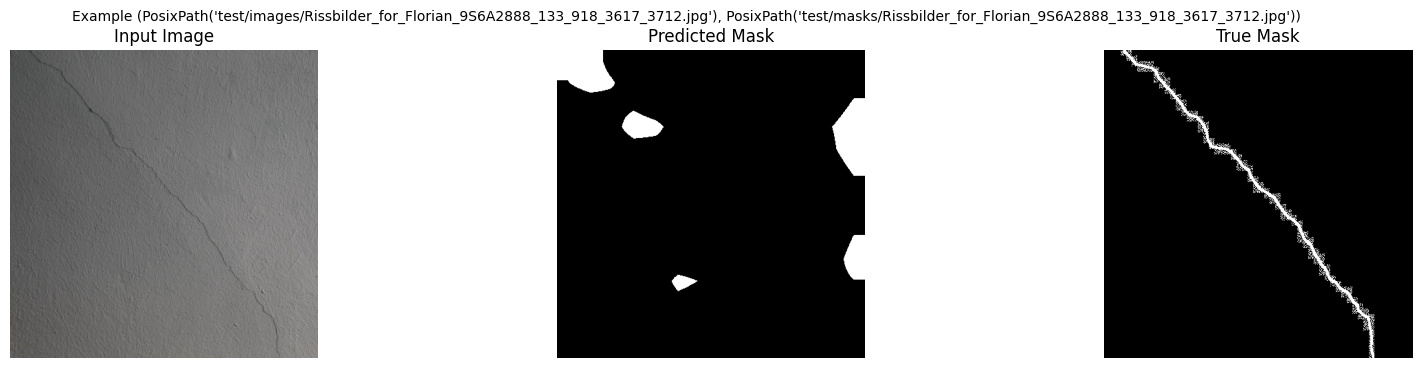

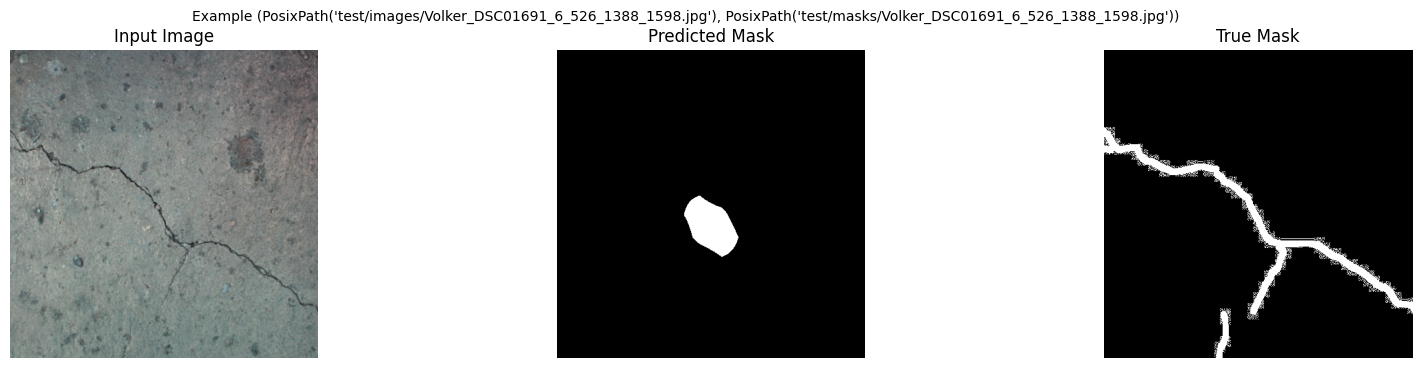

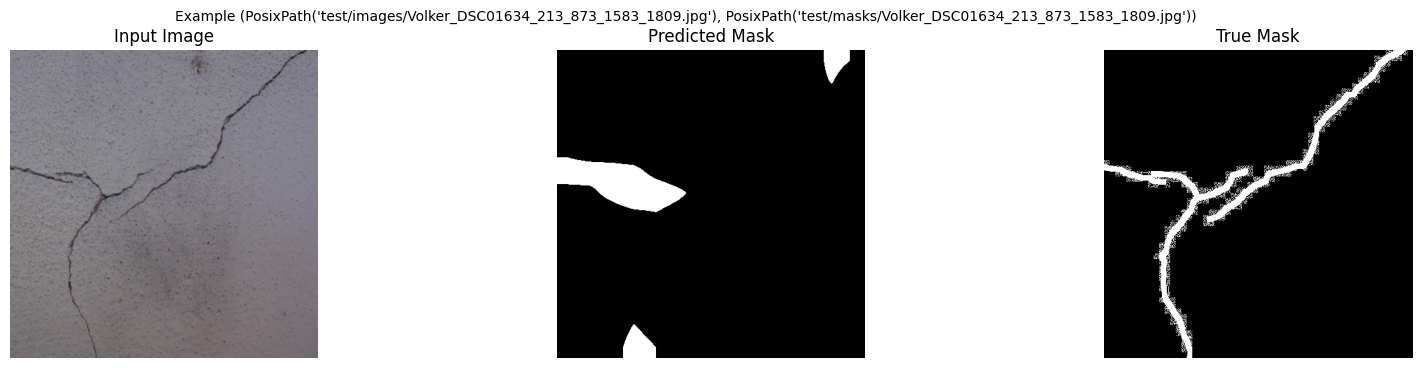

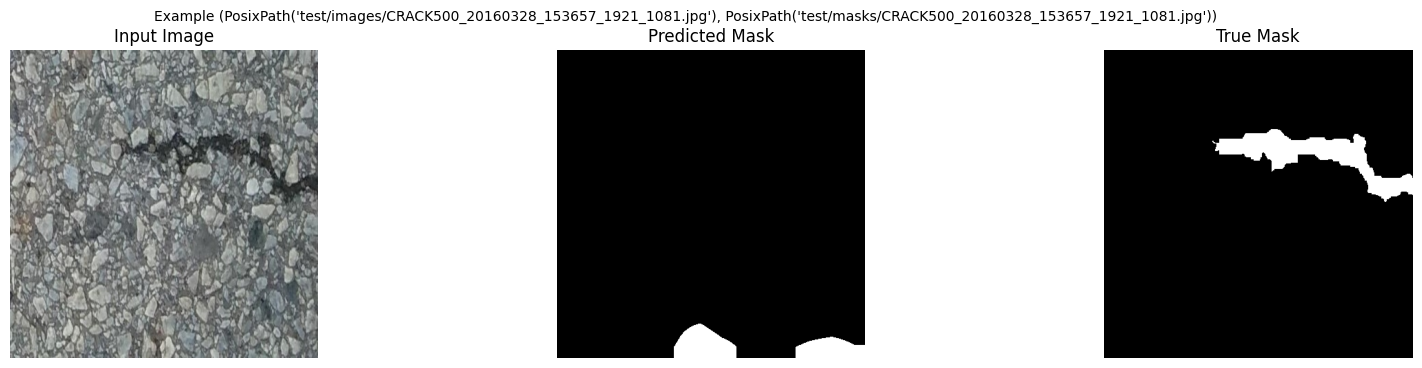

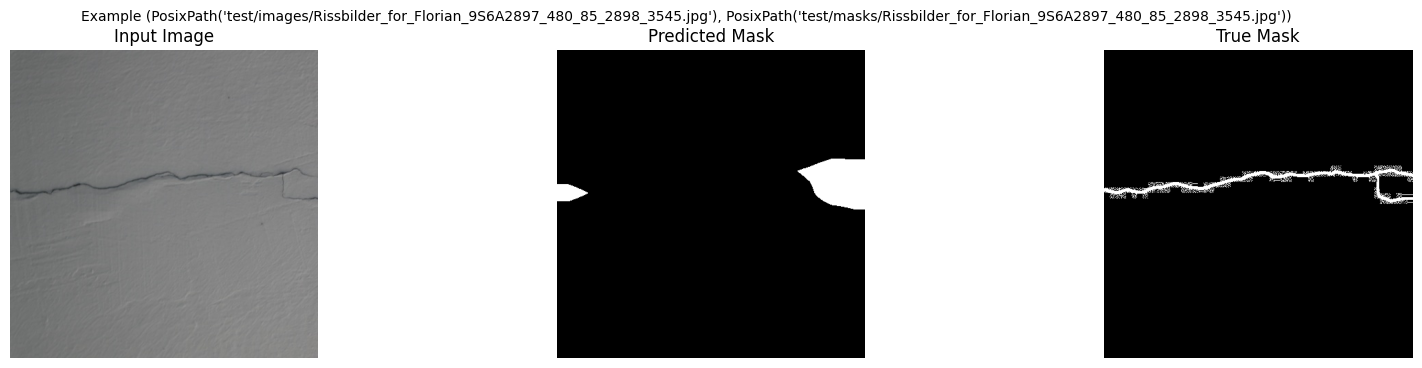

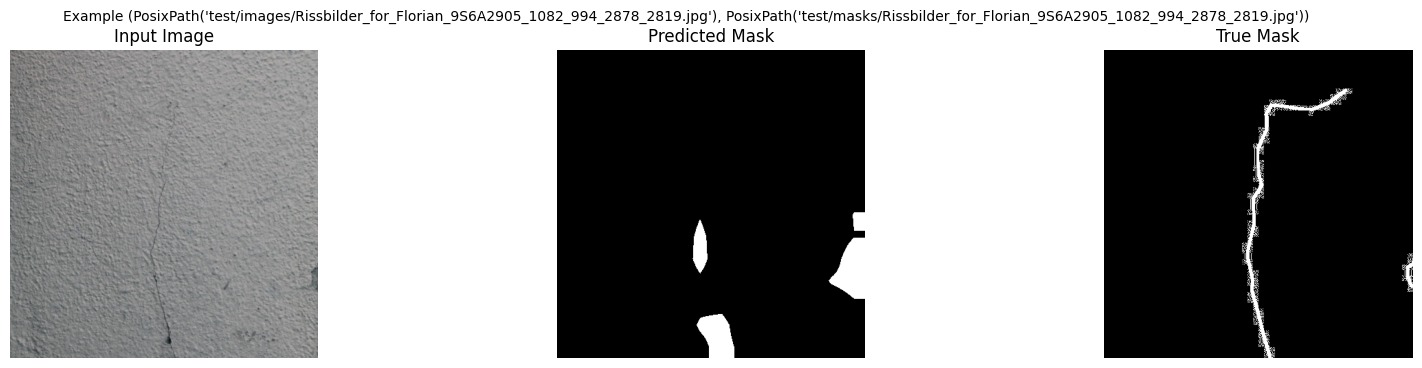

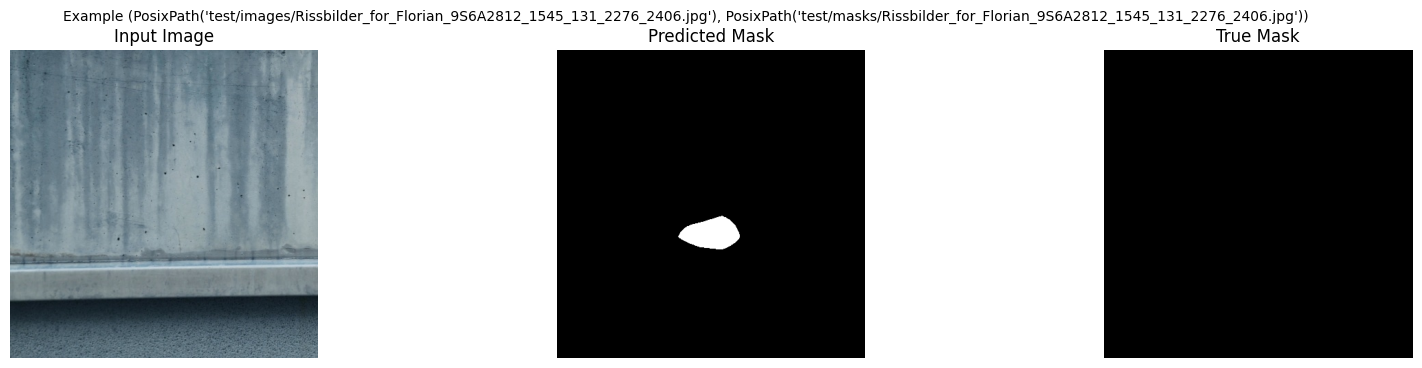

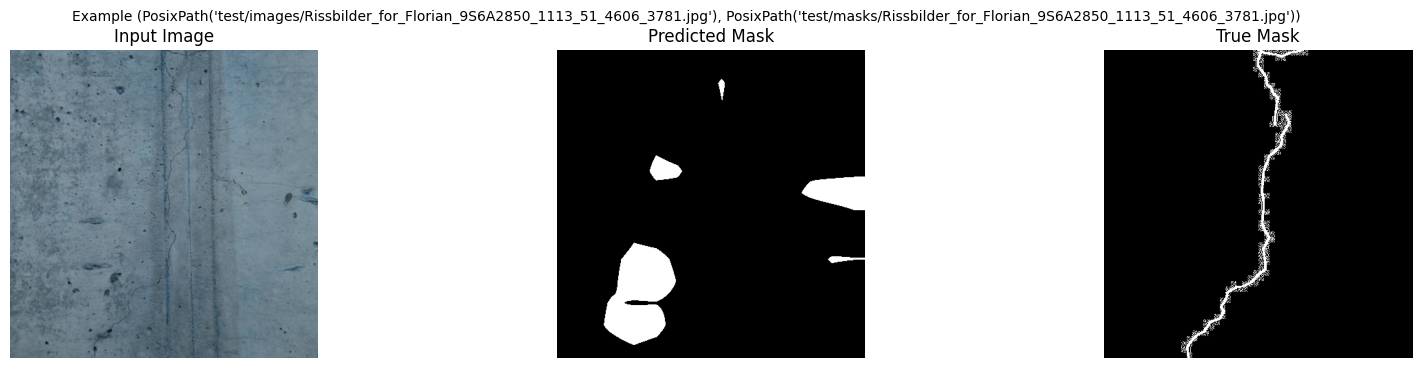

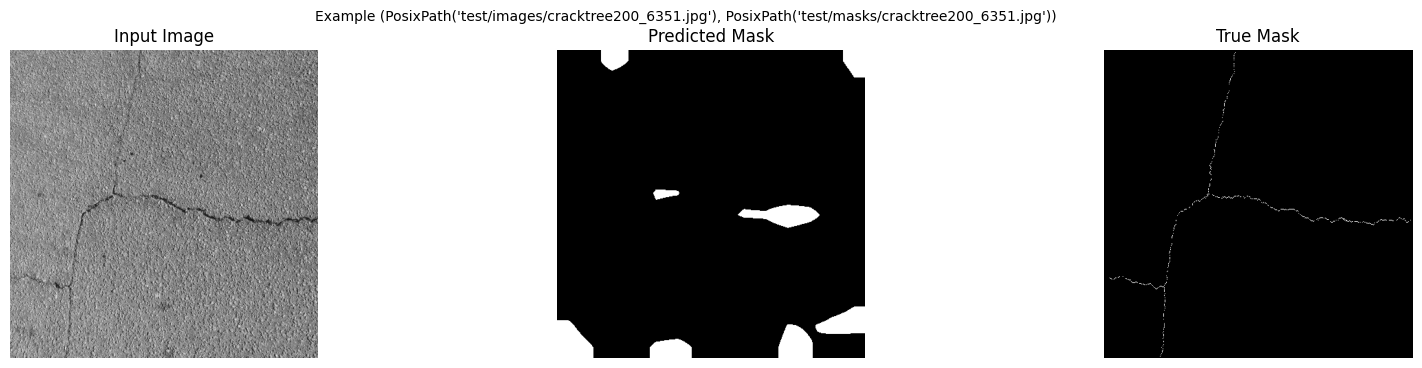

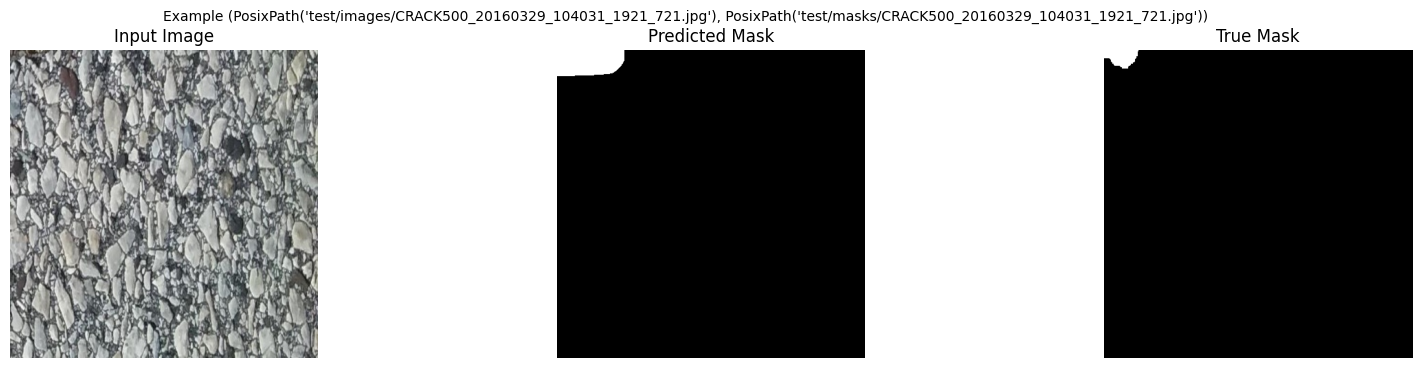

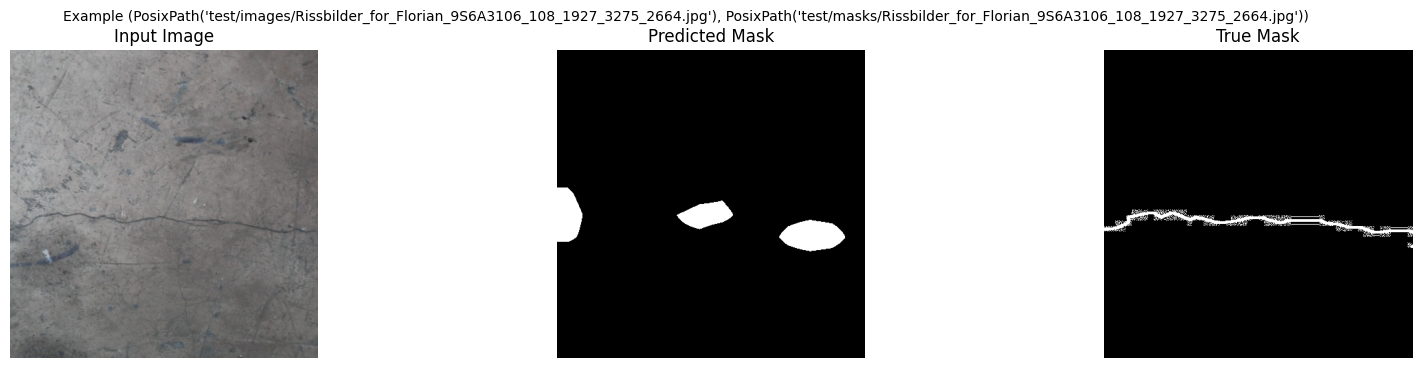

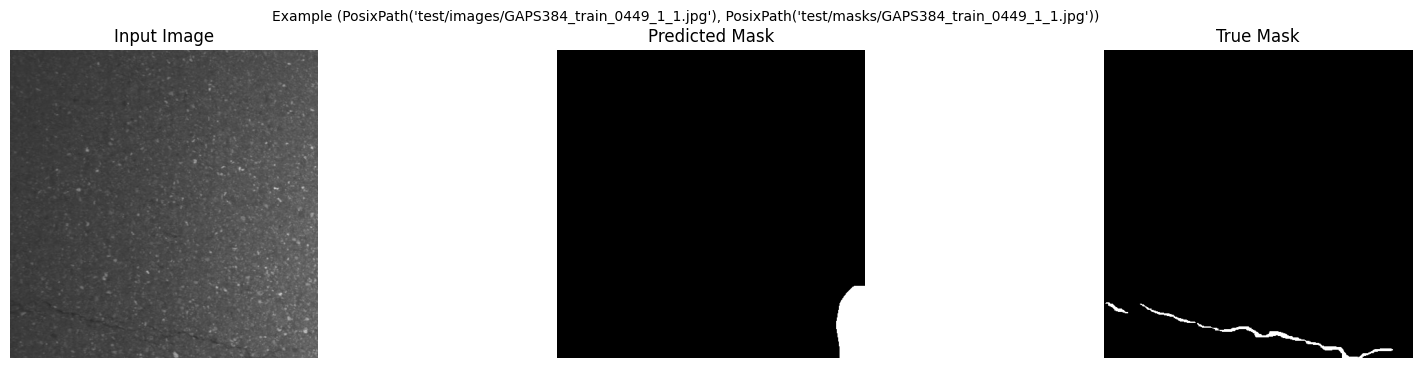

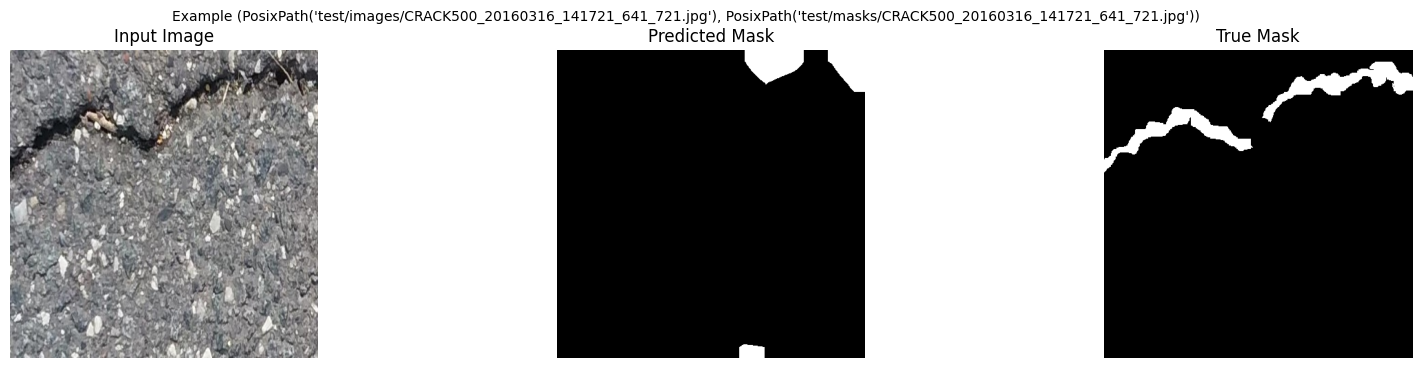

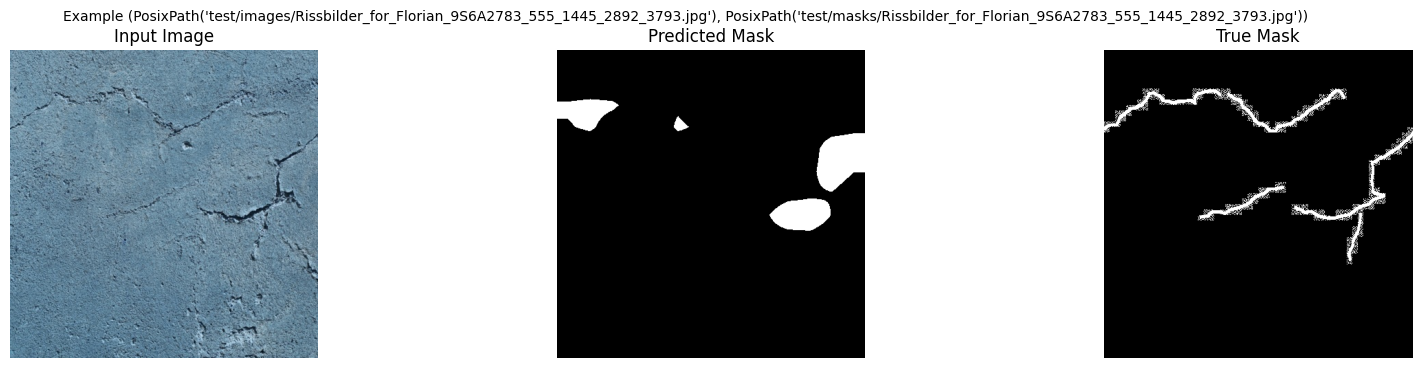

In [56]:
model.eval()
# test_examples = list_examples(Path("test"))
test_dataset = CrackSegmentationDataset(test_examples, augment=False)

evaluate_on_dataset(test_dataset)

# visualize
for i in range(20):
    image, mask = test_dataset[i]
    image = image.unsqueeze(0).to(device)
    pred_mask = (inference(model, image) > 0.5).float()

    plt.figure(figsize=(20, 4))
    plt.suptitle(f"Example {test_dataset.paths[i]}", fontsize=10)

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(image.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask.squeeze(0).squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("True Mask")
    plt.imshow(mask.squeeze().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    plt.show()

In [93]:
def mask2rle(img):
    '''
    img: numpy array, 1 -> mask, 0 -> background
    Returns run length as string formated
    '''
    pixels= img.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [94]:
rows = []
batch_size = 16

for i in tqdm(range(0, len(test_dataset), batch_size)):
    batch_indices = list(range(i, min(i + batch_size, len(test_dataset))))
    
    images = torch.stack([test_dataset[idx][0] for idx in batch_indices]).to(device)
    filenames = [Path(test_dataset.paths[idx][0]).name for idx in batch_indices]
    
    pred_masks = (inference(model, images)).cpu().numpy()  # (B,H,W)
    
    for filename, pred_mask in zip(filenames, pred_masks):
        cracks = mask2rle(pred_mask > 0.5)
        rows.append({"file": filename, "crack": cracks})

df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)


  0%|          | 0/106 [00:00<?, ?it/s]

In [95]:
df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)

In [96]:
df[df["file"] == "noncrack_noncrack_concrete_wall_82_27.jpg.jpg"]

,file,crack
0,noncrack_noncrack_concrete_wall_82_27.jpg.jpg,


                                                file  \
0      noncrack_noncrack_concrete_wall_82_27.jpg.jpg   
1  Rissbilder_for_Florian_9S6A2877_472_1716_2206_...   
2                  Volker_DSC01695_0_0_2736_1824.jpg   
3  Rissbilder_for_Florian_9S6A2857_807_939_2369_1...   
4  Rissbilder_for_Florian_9S6A2886_984_32_2437_25...   

                                               crack  
0                                                NaN  
1  353 58 801 58 1249 58 1697 58 2145 58 2593 58 ...  
2  400 2 848 2 1296 2 1744 2 2192 2 2640 2 3088 2...  
3  173377 17 173825 18 174273 20 174721 22 175169...  
4  166209 16 166657 18 167105 19 167553 21 168001...  


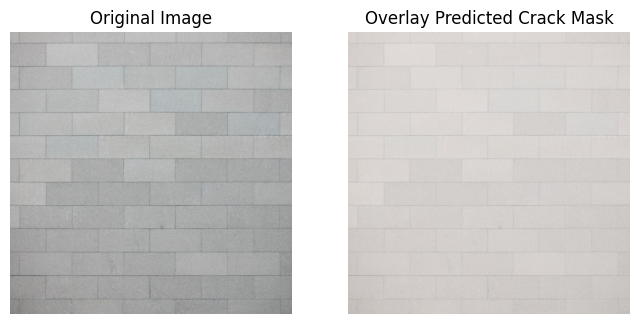

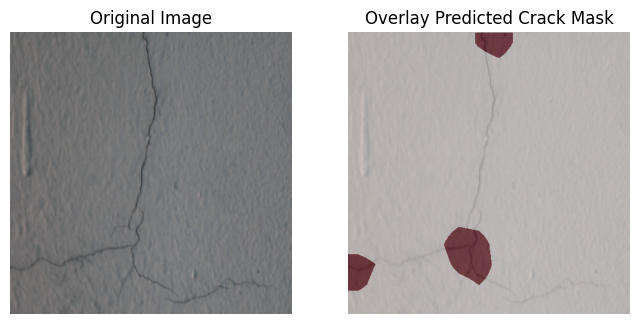

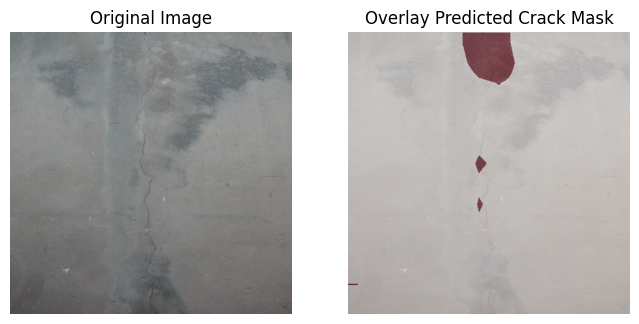

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# --- Load CSV ---
df = pd.read_csv("predicted_cracks.csv")
print(df.head())

# --- Helper: decode RLE into mask ---
def rle_decode(rle, shape):
    """
    rle: string of start length pairs, e.g. "230 8 678 9"
    shape: (H, W)
    """
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    if pd.isna(rle) or rle.strip() == "":
        return mask.reshape(shape)
    
    parts = list(map(int, rle.strip().split()))
    for i in range(0, len(parts), 2):
        start = parts[i]
        length = parts[i+1]
        mask[start:start+length] = 1
    return mask.reshape(shape)

# --- Pick a few examples to visualize ---
example_rows = df.sample(3)  # pick 3 random rows
selected_files = [p[0].name for p in test_dataset.paths[:3]]
example_rows = df[df["file"].isin(selected_files)]

for _, row in example_rows.iterrows():
    img_path = Path("test/images") / row["file"]  # adjust path if needed
    image = np.array(Image.open(img_path).convert("RGB")) / 255.0  # normalize for visualization
    H, W, _ = image.shape
    
    mask = rle_decode(row["crack"], (H, W))
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    plt.imshow(mask.T, alpha=0.5, cmap="Reds")
    plt.title("Overlay Predicted Crack Mask")
    plt.axis("off")
    
    plt.show()
